In [1]:
from utils.utils import DataLoader, DopplerDataset, plot_learning_curves
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


In [2]:
l_exp = [f"Regression/BET_Reg_32CH"] # Regression/Reg_1

data_loader = DataLoader(base_path, exp_list=all)

for exp in l_exp :
    #exp = "DefaultExp"
    print(f"🔔 Starting {exp}")
    stream = open(f"exp_list/{exp}.yaml", 'r')
    param  = yaml.safe_load(stream)
    param["TRAINING"]["DEVICE"] = 'mps'

    resultsPath = os.path.join("results", exp)

    # Create the directory
    if not os.path.exists(resultsPath):
        os.makedirs(resultsPath)

    myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

    # Train the network
    #train_losses, val_losses =  myNetwork.train()

    # Test the network
    myNetwork.loadWeight()
    myNetwork.test()   





🔄 Chargement des données: 100%|██████████| 50/50 [00:01<00:00, 31.06exp/s]


🔔 Starting Regression/BET_Reg_32CH
✅ Network Initialized


RuntimeError: Error(s) in loading state_dict for DopplerNetRegression:
	Missing key(s) in state_dict: "fc3.weight", "fc3.bias", "fc4.weight", "fc4.bias". 
	size mismatch for fc1.weight: copying a param with shape torch.Size([64, 32769]) from checkpoint, the shape in current model is torch.Size([256, 32769]).
	size mismatch for fc1.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for fc2.weight: copying a param with shape torch.Size([1, 64]) from checkpoint, the shape in current model is torch.Size([128, 256]).
	size mismatch for fc2.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current model is torch.Size([128]).

In [ ]:
num_params = sum(p.numel() for p in myNetwork.model.parameters())
print(f"Number of parameters: {num_params}") 
# V1 = 2.147.874.498
# V2 = 8.482.754
# V3 = 2.190.530
# V_reg = 2.190.465
# V_reg_48CH = 12.833.441

Number of parameters: 12833441


[72.61604944 37.28659027 37.28214773 37.28634005 37.28781095 37.28888642
 37.28795711 37.29033926 37.28849397 37.28825209 37.28792578 37.2879646
 37.28651604 37.29003376 37.28730775 37.28934298 37.28605825 37.28801666
 37.2886414  37.28313431 37.28569245 37.28646841 37.28978595 37.28936786
 37.28937138 37.29136775 37.28763811 37.29064928 37.28937047 37.28783692
 37.28936509 37.29087396 37.28729866 37.28807316 37.28652659 37.28423777
 37.28802696 37.28605395 37.28709838 37.28680555]
[37.02164141 37.01478306 37.01260961 37.00918292 37.00332097 37.00807167
 37.01206463 37.00182363 37.01007584 37.00621873 37.00198039 37.00176128
 37.01591661 37.00516376 37.00273526 37.00194334 37.02889479 37.00281547
 37.00818562 37.0050588  37.00226929 37.03521853 37.01663863 37.00229547
 37.017744   37.00767524 37.01421111 37.00226254 37.00632998 37.00175222
 37.00177271 37.00299089 37.00507069 37.00306774 37.00212261 37.01167425
 37.00260138 37.00972314 37.00890762 37.00402686]


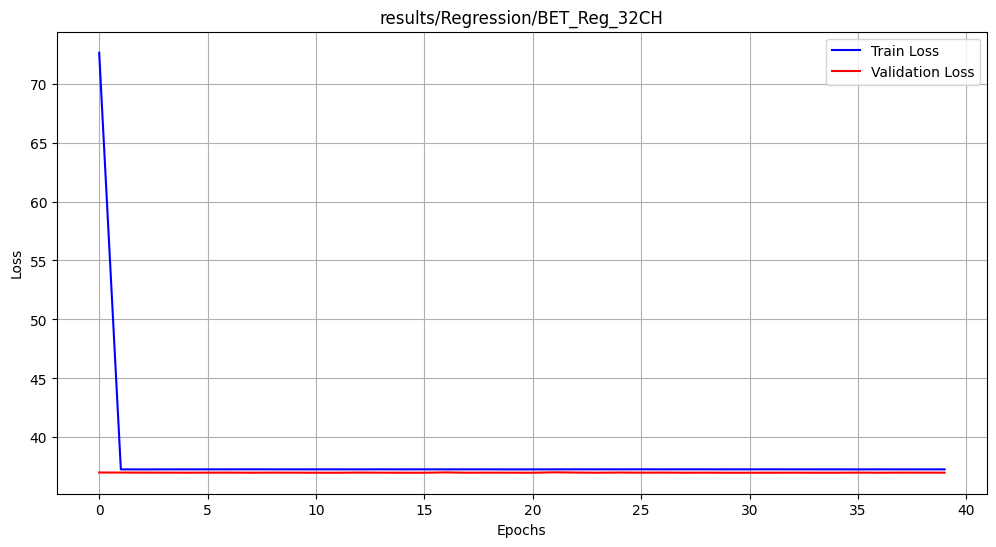

In [3]:
# Load learning curves
train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)
plot_learning_curves(train_losses, val_losses, resultsPath)